In [12]:
import pandas as pd

fund = pd.read_csv("data/raw/01_fund_master.csv")
nav = pd.read_csv("data/raw/02_nav_history (2).csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

print(fund.head())

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [13]:
nav.head

<bound method NDFrame.head of        amfi_code        date       nav
0         119551  2022-01-03   54.3856
1         119551  2022-01-04   54.3474
2         119551  2022-01-05   54.6869
3         119551  2022-01-06   55.4550
4         119551  2022-01-07   55.3692
...          ...         ...       ...
45995     149324  2026-05-25  292.4810
45996     149324  2026-05-26  291.2707
45997     149324  2026-05-27  288.8007
45998     149324  2026-05-28  280.6873
45999     149324  2026-05-29  279.7511

[46000 rows x 3 columns]>

In [18]:
import numpy as np
import pandas as pd

result = []

for code, data in nav.groupby("amfi_code"):

    returns = data["daily_return"].dropna()

    if len(returns) > 20:

        var = np.percentile(returns, 5)

        cvar = returns[returns <= var].mean()

        result.append([code, var, cvar])

report = pd.DataFrame(
    result,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR"
    ]
)

report.to_csv(
    "var_cvar_report.csv",
    index=False
)

report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


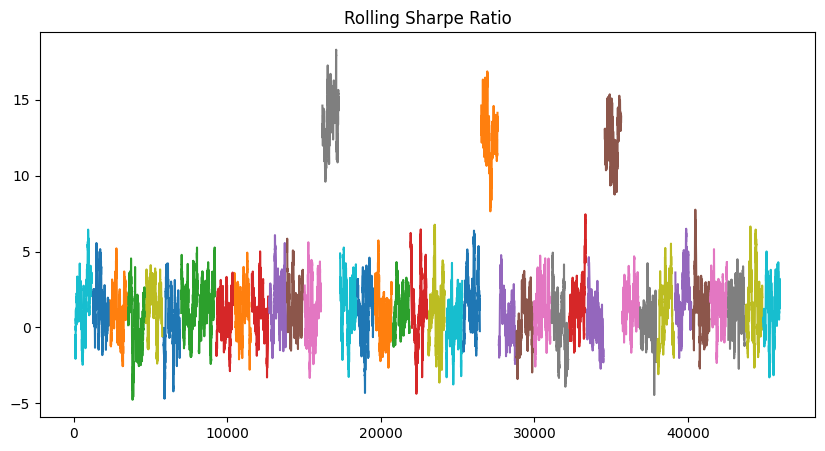

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for code, data in nav.groupby("amfi_code"):

    r = data["daily_return"]

    sharpe = (
        r.rolling(90).mean()
        /
        r.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(sharpe)

plt.title("Rolling Sharpe Ratio")

plt.savefig("rolling_sharpe_chart.png")

plt.show()